In [34]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [35]:
# Configuration du notebook
EXTRA_COLS = ['clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']
IN_CHANNELS = 14 + len(EXTRA_COLS)  # Doit être 19
MODEL_NAME  = 'model_california_cnn_gru'

In [36]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=10):
        super(CNNFeatureExtractor, self).__init__()
        # Premier bloc : 128 filtres, Kernel 7
        self.conv1 = nn.Conv1d(in_channels, 128, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)
        
        # Deuxième bloc : 64 filtres, Kernel 7
        self.conv2 = nn.Conv1d(128, 64, kernel_size=7, padding=3)
        self.bn2 = nn.BatchNorm1d(64)
        self.drop2 = nn.Dropout(0.2)
        
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: [B, T, C] -> [B, 10, 36]
        x = x.transpose(1, 2)
        
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.drop1(x)
        x = self.pool(x) # Réduit T à 18
        
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.drop2(x)
        
        return x.transpose(1, 2) # [B, 18, 64]


class BiGRUProcessor(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128):
        super(BiGRUProcessor, self).__init__()
        # Stacked Bi-GRU : 128 units puis 64 units
        self.gru1 = nn.GRU(input_dim, 128, batch_first=True, bidirectional=True)
        self.gru2 = nn.GRU(256, 64, batch_first=True, bidirectional=True)
        # Sortie finale : 64 * 2 (bidir) = 128
        
    def forward(self, x):
        # x shape: [B, 18, 64]
        out, _ = self.gru1(x)  # out: [B, 18, 256]
        out, _ = self.gru2(out) # out: [B, 18, 128]
        return out
    


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim=128):
        super(TemporalAttention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: [B, T_reduced, 128]
        # 1. Calcul des scores (énergie)
        energy = self.attn(x) # [B, 18, 1]
        
        # 2. Normalisation Softmax
        weights = torch.softmax(energy, dim=1)
        
        # 3. Somme pondérée (contexte)
        context = torch.sum(weights * x, dim=1) # [B, 128]
        return context, weights
    





class HybridCropNet(nn.Module):
    def __init__(self, num_classes, in_channels=10):
        super(HybridCropNet, self).__init__()
        
        # 1. Extraction des caractéristiques locales (CNN)
        # Sortie après pool: [B, 18, 64]
        self.feature_extractor = CNNFeatureExtractor(in_channels=in_channels)
        
        # 2. Modélisation de la séquence (Bi-GRU)
        # Sortie: [B, 18, 128]
        self.sequence_processor = BiGRUProcessor(input_dim=64, hidden_dim=128)
        
        # 3. Focus sur les dates clés (Attention)
        # Sortie: [B, 128]
        self.attention = TemporalAttention(hidden_dim=128)
        
        # 4. Classification finale (MLP)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: [Batch, 36, 10]
        
        # Phase 1: CNN
        # On réduit la dimension temporelle et on enrichit les features
        x = self.feature_extractor(x) 
        
        # Phase 2: Bi-GRU
        # On capture la dynamique de croissance (aller-retour)
        x = self.sequence_processor(x)
        
        # Phase 3: Attention
        # On pondère les 18 étapes temporelles restantes
        context_vector, weights = self.attention(x)
        
        # Phase 4: MLP
        # Décision finale basée sur le résumé pondéré
        logits = self.classifier(context_vector)
        
        return logits, weights

In [37]:
df_cali = pd.read_csv('../data/california_preprocessed_v2.csv')
df_cali.head()

,d0_B2,d0_B3,d0_B4,d0_B5,d0_B6,d0_B7,d0_B8,d0_B8A,d0_B11,d0_B12,...,d35_B8A,d35_B11,d35_B12,clim_precip,clim_temp,soil_texture,topo_elevation,topo_slope,cropland,target_class
0,0.04820,0.06105,0.06470,0.09330,0.13855,0.15165,0.17355,0.17550,0.21355,0.15090,...,0.00000,0.00000,0.00000,0.397416,-0.651279,0.525297,-0.433458,-0.330163,76,4
1,0.06170,0.08805,0.10080,0.13435,0.19605,0.21765,0.23495,0.23375,0.27285,0.23035,...,0.00000,0.00000,0.00000,0.132386,1.235055,0.525297,-0.583178,-0.612763,36,2
2,0.04420,0.06350,0.10130,0.11880,0.13210,0.15020,0.17570,0.18160,0.24420,0.20890,...,0.41005,0.29705,0.24475,-1.015309,0.950606,0.525297,-0.266627,-0.443951,69,0
3,0.08615,0.10970,0.14635,0.16965,0.18835,0.20460,0.22510,0.23185,0.33110,0.25865,...,0.00000,0.00000,0.00000,-1.032278,1.098399,0.525297,-0.561790,-0.781662,36,2
4,0.24455,0.24090,0.25870,0.27515,0.27545,0.28775,0.30590,0.30050,0.38235,0.33175,...,0.00000,0.00000,0.00000,0.049402,1.259696,1.146951,-0.608845,-0.512391,36,2


In [38]:
mapping = {69: 0, 3: 1, 36: 2, 75: 3, 76: 4, 176: 5}
def map_classes(val):
    return mapping.get(val, 5)

df_cali['target_class'] = df_cali['cropland'].apply(map_classes)

targets = {0: 2054, 1: 2037, 2: 974, 3: 783, 4: 640, 5: 3512}
sampled_dfs = []
for class_id, count in targets.items():
    sub_df = df_cali[df_cali['target_class'] == class_id]
    sampled_dfs.append(sub_df.sample(n=min(len(sub_df), count), random_state=42))

df_cali_final = pd.concat(sampled_dfs).sample(frac=1, random_state=42)
print(df_cali_final['target_class'].value_counts())

target_class
5    3512
0    2054
1    2037
2     974
3     783
4     640
Name: count, dtype: int64


In [39]:
print(df_cali['target_class'].value_counts())
print(f"Total : {len(df_cali)}")

target_class
5    3512
0    2054
1    2037
2     974
3     783
4     640
Name: count, dtype: int64
Total : 10000


In [40]:
def prepare_mixed_hybrid_data(df, extra_cols):
    """
    Prépare les données en mode 'Mixte' (14 spectrales + 5 environnementales).
    Total features par date : 19
    Format de sortie : [Batch, 36, 19]
    """
    BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    
    # 1. Calcul des indices (Ton bloc actuel)
    for i in range(36):
        b3, b4, b5, b8 = df[f'd{i}_B3'], df[f'd{i}_B4'], df[f'd{i}_B5'], df[f'd{i}_B8']
        df[f'd{i}_NDVI']  = (b8 - b4) / (b8 + b4 + 1e-8)
        df[f'd{i}_NDRE']  = (b8 - b5) / (b8 + b5 + 1e-8)
        df[f'd{i}_LCI']   = (b8 - b5) / (b8 + b4 + 1e-8)
        df[f'd{i}_GNDVI'] = (b8 - b3) / (b8 + b3 + 1e-8)

    # 2. Extraction des 14 features spectrales
    PURE_FEATURES = BANDS + ['NDVI', 'NDRE', 'LCI', 'GNDVI']
    ordered_cols = [f'd{i}_{feat}' for i in range(36) for feat in PURE_FEATURES]
    x_spectral = torch.tensor(df[ordered_cols].values, dtype=torch.float32).view(-1, 36, 14)
    
    # 3. Intégration des 5 EXTRA_COLS (Mode Contextuel)
    if extra_cols and len(extra_cols) > 0:
        # On prend les colonnes statiques (ex: elevation, soil_texture)
        x_extra = torch.tensor(df[extra_cols].values, dtype=torch.float32)
        # On les "étire" sur les 36 dates : [Batch, 5] -> [Batch, 36, 5]
        x_extra_expanded = x_extra.unsqueeze(1).expand(-1, 36, -1)
        # Fusion : [Batch, 36, 14 + 5] = [Batch, 36, 19]
        x_final = torch.cat([x_spectral, x_extra_expanded], dim=-1)
    else:
        x_final = x_spectral
    
    y = torch.tensor(df['target_class'].values, dtype=torch.long)
    return x_final, y

# --- Utilisation ---
EXTRA_COLS = ['clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']
IN_CHANNELS = 14 + len(EXTRA_COLS) # 19

x_cal, y_cal = prepare_mixed_hybrid_data(df_cali_final, EXTRA_COLS)

print(f'Nouveau Shape X: {x_cal.shape}') # Doit être [Batch, 36, 19]

Nouveau Shape X: torch.Size([10000, 36, 19])


/tmp/ipykernel_9664/1529731693.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'd{i}_NDVI']  = (b8 - b4) / (b8 + b4 + 1e-8)
/tmp/ipykernel_9664/1529731693.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'd{i}_NDRE']  = (b8 - b5) / (b8 + b5 + 1e-8)
/tmp/ipykernel_9664/1529731693.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-f

In [41]:
# Split simplifié (sans les masques)
x_train, x_temp, y_train, y_temp = train_test_split(
    x_cal, y_cal, test_size=0.18, stratify=y_cal, random_state=96
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.8, stratify=y_temp, random_state=96
)

# Loaders propres
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val, y_val),   batch_size=256)
test_loader  = DataLoader(TensorDataset(x_test, y_test),  batch_size=256)

In [42]:
import copy
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 40
best_f1 = 0.0
print(f'Device utilisé : {device}')

# 1. Instanciation du nouveau modèle (on passe à 10 canaux)
model = HybridCropNet(num_classes=6, in_channels=IN_CHANNELS).to(device)

# 2. Optimizer avec Weight Decay (L2) - Crucial pour les RNN
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()

best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f'Époque {epoch+1}/{epochs}', unit='batch')
    
    for b_x, b_y in pbar: # On a enlevé b_mask si tu as nettoyé ton DataLoader
        b_x, b_y = b_x.to(device), b_y.to(device)
        
        optimizer.zero_grad()
        # Le modèle renvoie (logits, weights), on ne prend que les logits ici
        outputs, _ = model(b_x) 
        
        loss = criterion(outputs, b_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0
    with torch.no_grad():
        for b_x, b_y in val_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            
            outputs, _ = model(b_x)
            val_loss += criterion(outputs, b_y).item()
            
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(b_y.cpu().numpy())

    # Calcul des métriques
    precision, recall, f1, _ = precision_recall_fscore_support(
        val_targets, val_preds, average='macro', zero_division=0
    )
    val_acc = 100 * np.sum(np.array(val_preds) == np.array(val_targets)) / len(val_targets)
    
    print(f'\n[Validation] Loss: {val_loss/len(val_loader):.4f} | Acc: {val_acc:.2f}%')
    print(f'[Scores] Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}\n')

    if f1 > best_f1:
        best_f1 = f1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f'🔥 Nouveau record ! Meilleur modèle mis à jour (F1: {best_f1:.4f})')

# Rechargement du meilleur état
model.load_state_dict(best_model_state)
print(f'\nEntraînement fini. Meilleur F1 atteint: {best_f1:.4f}')

Device utilisé : cuda


Époque 1/40: 100%|██████████| 33/33 [00:00<00:00, 93.66batch/s, loss=0.5879] 



[Validation] Loss: 0.6765 | Acc: 70.56%
[Scores] Precision: 0.4705 | Recall: 0.5227 | F1-Score: 0.4824

🔥 Nouveau record ! Meilleur modèle mis à jour (F1: 0.4824)


Époque 2/40: 100%|██████████| 33/33 [00:00<00:00, 94.64batch/s, loss=1.6002] 



[Validation] Loss: 0.5350 | Acc: 80.56%
[Scores] Precision: 0.6701 | Recall: 0.6431 | F1-Score: 0.6415

🔥 Nouveau record ! Meilleur modèle mis à jour (F1: 0.6415)


...


[Validation] Loss: 0.2374 | Acc: 90.00%
[Scores] Precision: 0.8641 | Recall: 0.8522 | F1-Score: 0.8563



Époque 39/40: 100%|██████████| 33/33 [00:00<00:00, 87.95batch/s, loss=0.4001]



[Validation] Loss: 0.2631 | Acc: 88.61%
[Scores] Precision: 0.8410 | Recall: 0.8440 | F1-Score: 0.8367



Époque 40/40: 100%|██████████| 33/33 [00:00<00:00, 88.55batch/s, loss=0.2219]



[Validation] Loss: 0.2664 | Acc: 87.78%
[Scores] Precision: 0.8512 | Recall: 0.8228 | F1-Score: 0.8336


Entraînement fini. Meilleur F1 atteint: 0.8690


In [43]:
torch.save(model.state_dict(), f'models/model_california_all.pth')
print('Modèle sauvegardé : model_california_all.pth')

Modèle sauvegardé : model_california_all.pth


=== Test Set - HybridCropNet ===
OA    : 0.8875
Kappa : 0.8541
              precision    recall  f1-score   support

      Grapes       0.85      0.79      0.82       296
        Rice       1.00      0.98      0.99       293
     Alfalfa       0.94      0.81      0.87       140
     Almonds       0.60      0.66      0.63       113
  Pistachios       0.70      0.77      0.74        92
      Others       0.93      0.98      0.96       506

    accuracy                           0.89      1440
   macro avg       0.84      0.83      0.83      1440
weighted avg       0.89      0.89      0.89      1440



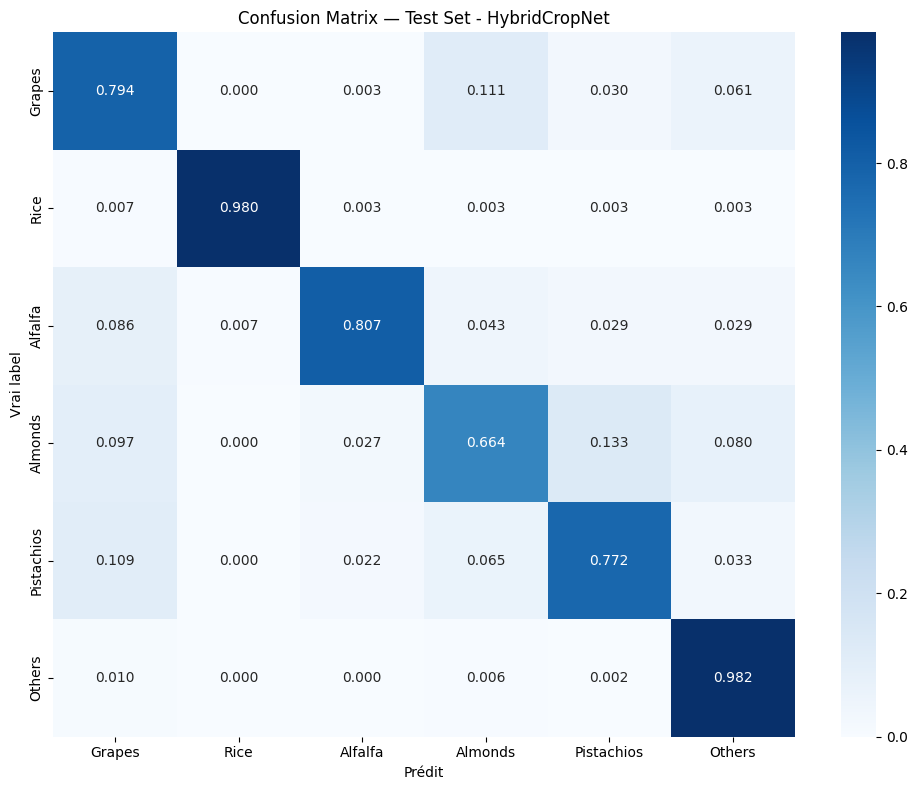

In [44]:
def evaluate_on_test(model, test_loader, class_names, title):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        # 1. On unpack seulement 2 valeurs (X et Y)
        for b_x, b_y in test_loader:
            b_x, b_y = b_x.to(device), b_y.to(device)
            
            # 2. On unpack les 2 sorties du nouveau modèle (logits et weights)
            outputs, _ = model(b_x) 
            
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(b_y.cpu().numpy())
            
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calcul des métriques globales
    oa    = (all_preds == all_labels).mean()
    kappa = cohen_kappa_score(all_labels, all_preds)
    
    print(f'=== {title} ===')
    print(f'OA    : {oa:.4f}')
    print(f'Kappa : {kappa:.4f}')
    
    # Rapport détaillé par classe (c'est là qu'on verra le score des Amandes !)
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.3f', xticklabels=class_names,
                yticklabels=class_names, cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    
    # Sauvegarde
    os.makedirs('./figs', exist_ok=True)
    plt.savefig(f'./figs/CNNGRU_confusion_matrix.png', dpi=150)
    plt.show()


class_names = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
evaluate_on_test(model, test_loader, class_names, title='Test Set - HybridCropNet')